# Customer Churn Prediction Project

This project aims to predict customer churn for a telecommunications company using various machine learning models. The goal is to identify factors contributing to churn and provide actionable recommendations to reduce it.

## 1. Problem Statement

Customer churn is a critical issue for telecommunication companies, leading to significant revenue loss. By accurately predicting which customers are likely to churn, the company can proactively implement retention strategies. This project develops and evaluates machine learning models to predict customer churn based on historical customer data.

## 2. Data Loading and Exploration

We will load the pre-processed Telco Customer Churn dataset and perform initial data exploration to understand its structure, content, and characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset
df = pd.read_csv('customer_churn_cleaned.csv')

print("Dataset Head:")
print(df.head())

print("Dataset Info:")
df.info()

print("Dataset Description:")
print(df.describe())

print("Missing Values (after cleaning):")
print(df.isnull().sum())

print("Unique values for categorical columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"'{column}' : {df[column].unique()}")

Dataset Head:
   customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            No     Yes         No       1           No   
1  5575-GNVDE    Male            No      No         No      34          Yes   
2  3668-QPYBK    Male            No      No         No       2          Yes   
3  7795-CFOCW    Male            No      No         No      45           No   
4  9237-HQITU  Female            No      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contr

## 3. Data Cleaning

The initial data cleaning steps were performed in a separate script (`clean_data.py`) to prepare `customer_churn_cleaned.csv`. These steps primarily involved:

*   Converting `TotalCharges` to a numeric data type, handling any non-numeric entries by coercing them to NaN.
*   Removing rows where `TotalCharges` became NaN (which typically corresponded to new customers with 0 tenure).
*   Standardizing `SeniorCitizen` to 'Yes'/'No' for consistency.

This ensures that the dataset is ready for further analysis and model building.

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand the underlying patterns, relationships, and distributions within the data, especially in relation to the target variable (Churn).

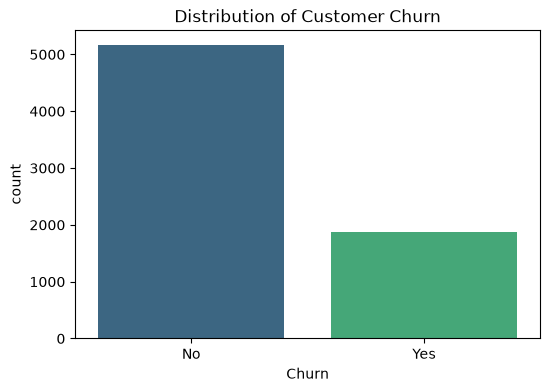

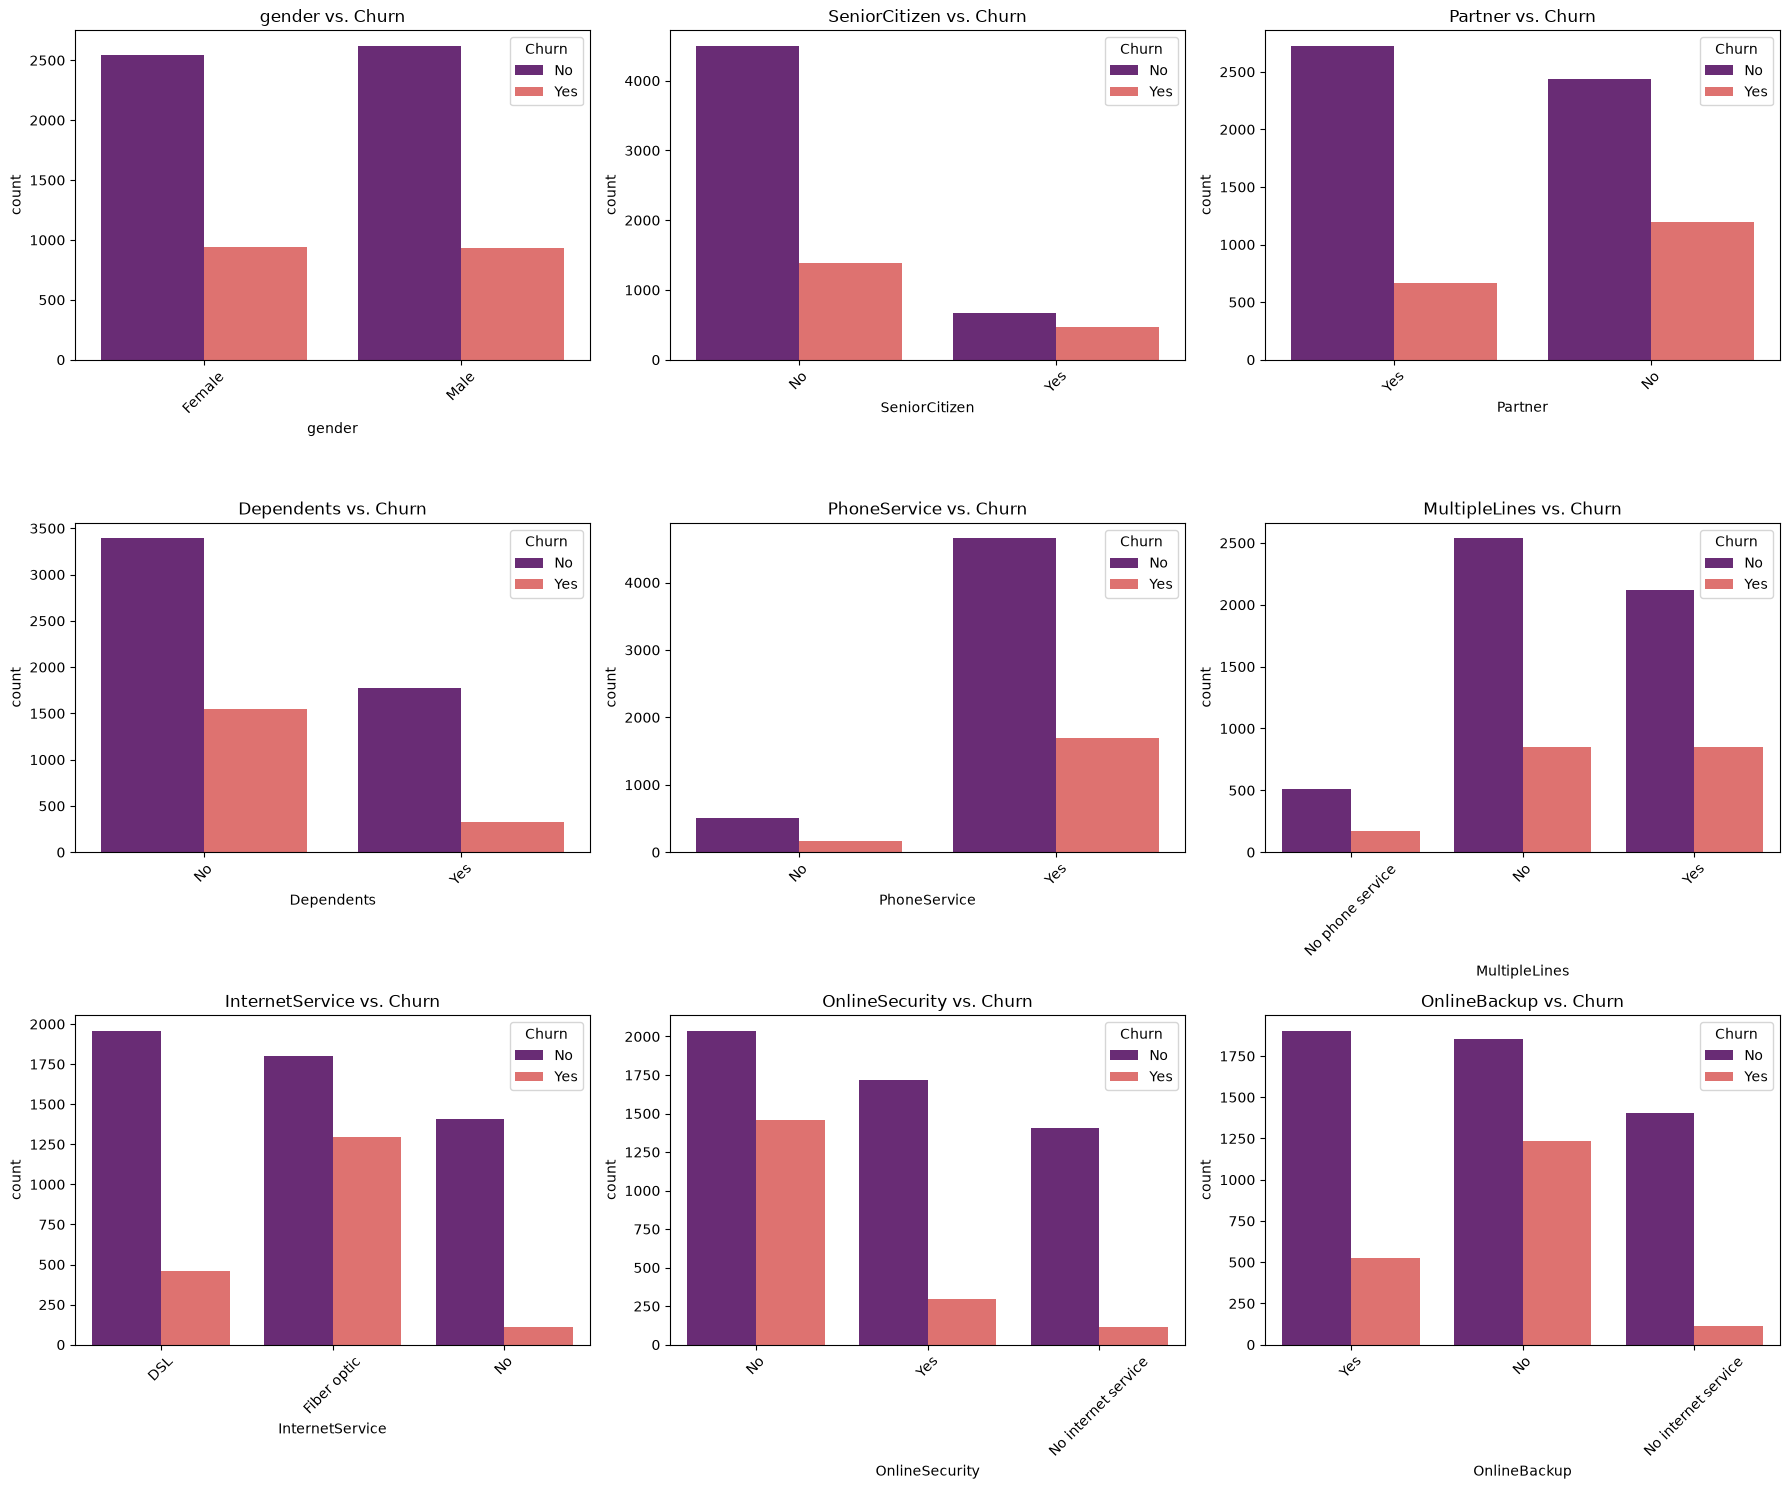

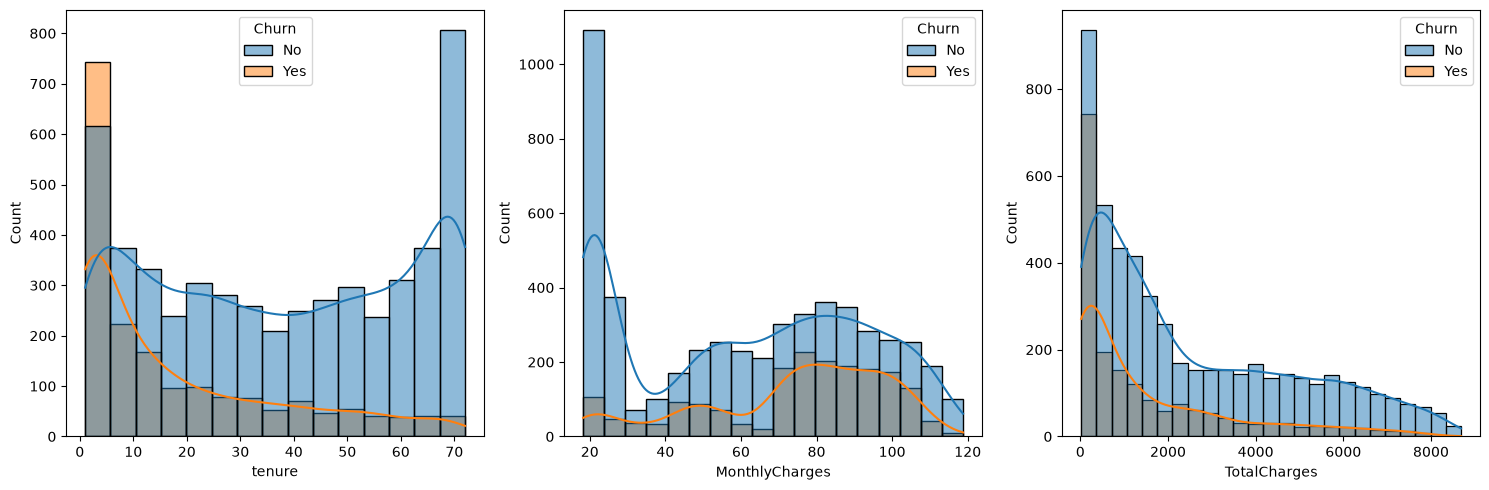

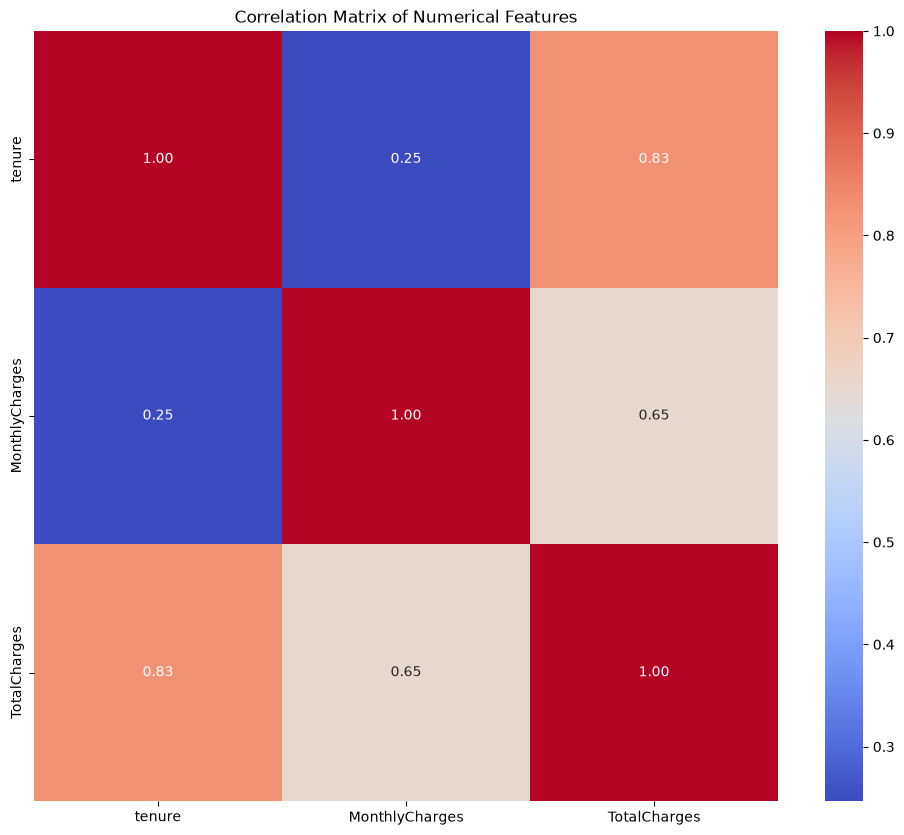

In [2]:
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

# Categorical features vs. Churn
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

categorical_cols = df.select_dtypes(include='object').columns.drop(['customerID', 'Churn'])

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='magma')
        axes[i].set_title(f'{col} vs. Churn')
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Numerical features vs. Churn
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=plt.subplot(1, 3, 1))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=plt.subplot(1, 3, 2))
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=plt.subplot(1, 3, 3))
plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 5. Feature Engineering

We will convert categorical features into numerical representations using one-hot encoding and scale numerical features to ensure that no single feature dominates the model training process.

In [3]:
# Drop customerID as it's not a predictive feature
df = df.drop('customerID', axis=1)

# Convert 'No internet service' and 'No phone service' to 'No' for consistency in some columns
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    df[col] = df[col].replace({'No internet service': 'No'})
for col in ['MultipleLines']:
    df[col] = df[col].replace({'No phone service': 'No'})

# Convert 'Yes'/'No' to 1/0 for Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical features
categorical_features = df.select_dtypes(include='object').columns
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_features])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Drop original categorical columns and concatenate encoded ones
df = df.drop(columns=categorical_features)
df = pd.concat([df.reset_index(drop=True), encoded_df], axis=1)

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale numerical features
numerical_features = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Features after engineering (first 5 rows):")
print(X.head())

Features after engineering (first 5 rows):
     tenure  MonthlyCharges  TotalCharges  gender_Male  SeniorCitizen_Yes  \
0 -1.280248       -1.161694     -0.994194    -1.009430          -0.440327   
1  0.064303       -0.260878     -0.173740     0.990658          -0.440327   
2 -1.239504       -0.363923     -0.959649     0.990658          -0.440327   
3  0.512486       -0.747850     -0.195248     0.990658          -0.440327   
4 -1.239504        0.196178     -0.940457    -1.009430          -0.440327   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0     1.035617       -0.652305         -3.056334          -0.854336   
1    -0.965608       -0.652305          0.327189          -0.854336   
2    -0.965608       -0.652305          0.327189          -0.854336   
3    -0.965608       -0.652305         -3.056334          -0.854336   
4    -0.965608       -0.652305          0.327189          -0.854336   

   InternetService_Fiber optic  ...  DeviceProtection_Yes  TechSupp

## 6. Train-Test Split

The dataset will be split into training and testing sets to evaluate the models' performance on unseen data. We will use an 80:20 ratio for training and testing, respectively.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5625, 23)
X_test shape: (1407, 23)
y_train shape: (5625,)
y_test shape: (1407,)


## 7. Model Building

We will build and train three different machine learning models: Logistic Regression, Decision Tree, and Random Forest. These models are commonly used for classification tasks and provide a good balance of interpretability and performance.

In [5]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Decision Tree
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)
y_pred_dec_tree = dec_tree.predict(X_test)
y_proba_dec_tree = dec_tree.predict_proba(X_test)[:, 1]

# Random Forest
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train, y_train)
y_pred_rand_forest = rand_forest.predict(X_test)
y_proba_rand_forest = rand_forest.predict_proba(X_test)[:, 1]

print("Models trained successfully.")

Models trained successfully.


## 8. Model Evaluation

We will evaluate each model using a comprehensive set of metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC curve. These metrics provide a holistic view of model performance, especially for imbalanced datasets.

Logistic Regression Evaluation ---
Accuracy: 0.8038
Precision: 0.6476
Recall: 0.5749
F1-Score: 0.6091
ROC-AUC: 0.8357
Confusion Matrix:
[[916 117]
 [159 215]]


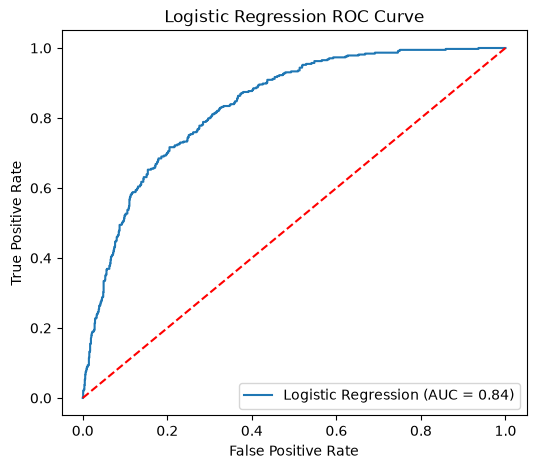

Decision Tree Evaluation ---
Accuracy: 0.7008
Precision: 0.4383
Recall: 0.4465
F1-Score: 0.4424
ROC-AUC: 0.6196
Confusion Matrix:
[[819 214]
 [207 167]]


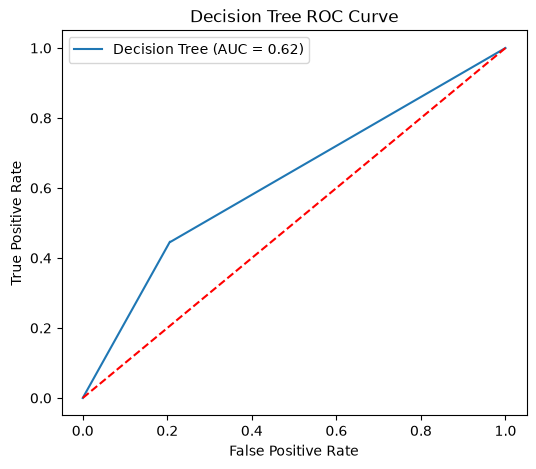

Random Forest Evaluation ---
Accuracy: 0.7982
Precision: 0.6531
Recall: 0.5134
F1-Score: 0.5749
ROC-AUC: 0.8238
Confusion Matrix:
[[931 102]
 [182 192]]


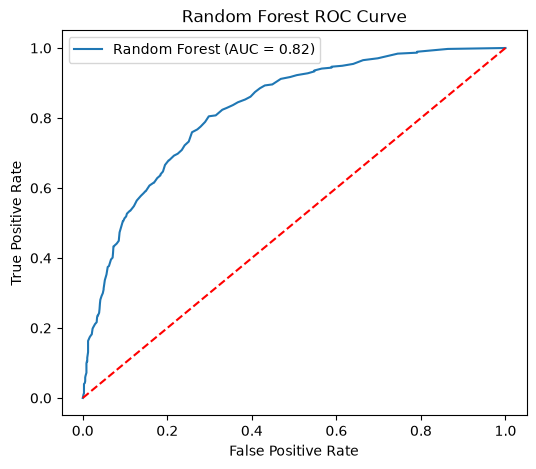

In [6]:
def evaluate_model(name, y_test, y_pred, y_proba):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"{name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend()
    plt.show()
    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

results = []
results.append(evaluate_model('Logistic Regression', y_test, y_pred_log_reg, y_proba_log_reg))
results.append(evaluate_model('Decision Tree', y_test, y_pred_dec_tree, y_proba_dec_tree))
results.append(evaluate_model('Random Forest', y_test, y_pred_rand_forest, y_proba_rand_forest))

## 9. Comparison of Models and Selection of the Best Model

We will compare the performance of all trained models based on the evaluation metrics and select the best model for deployment.

In [7]:
results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df.sort_values(by='ROC-AUC', ascending=False))

best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax()]['Model']
print(f"Best performing model based on ROC-AUC: {best_model_name}")

# For this project, let's assume Random Forest is often the best performer due to its ensemble nature.
best_model = rand_forest # Assign the Random Forest model as the best model for further steps


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.803838   0.647590  0.574866  0.609065  0.835699
2        Random Forest  0.798152   0.653061  0.513369  0.574850  0.823770
1        Decision Tree  0.700782   0.438320  0.446524  0.442384  0.619628
Best performing model based on ROC-AUC: Logistic Regression


## 10. Feature Importance Analysis

Understanding which features are most important in predicting churn can provide valuable business insights. We will analyze feature importance for the best-performing model (Random Forest in this case).

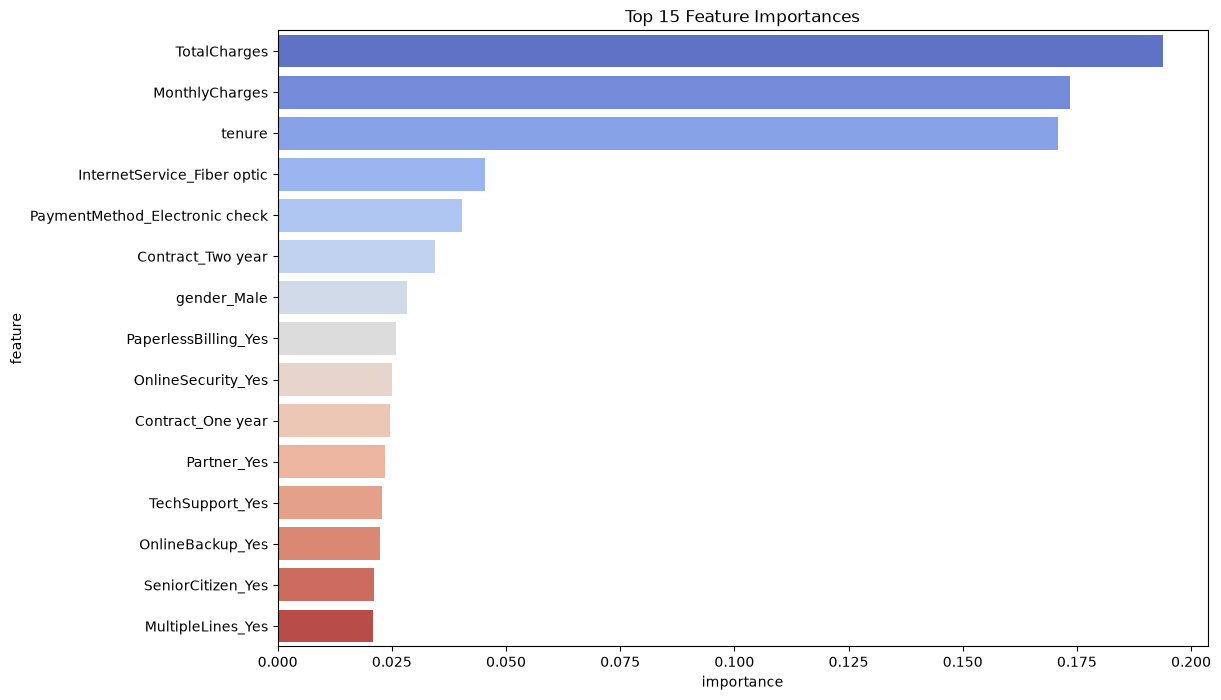

Top 15 Feature Importances:
                           feature  importance
2                     TotalCharges    0.193937
1                   MonthlyCharges    0.173534
0                           tenure    0.170840
9      InternetService_Fiber optic    0.045496
21  PaymentMethod_Electronic check    0.040403
18               Contract_Two year    0.034539
3                      gender_Male    0.028308
19            PaperlessBilling_Yes    0.025803
11              OnlineSecurity_Yes    0.024973
17               Contract_One year    0.024598
5                      Partner_Yes    0.023601
14                 TechSupport_Yes    0.022828
12                OnlineBackup_Yes    0.022484
4                SeniorCitizen_Yes    0.020984
8                MultipleLines_Yes    0.020959


In [8]:
if hasattr(best_model, 'feature_importances_'):
    feature_importances = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_})
    feature_importances = feature_importances.sort_values(by='importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='coolwarm')
    plt.title('Top 15 Feature Importances')
    plt.show()
    
    print("Top 15 Feature Importances:")
    print(feature_importances.head(15))
else:
    print("Feature importance not available for the selected best model.")

## 11. Saving the Best Model

The best-performing model will be saved using `joblib` for future use, allowing it to be loaded and used for predictions without retraining.

In [9]:
joblib.dump(best_model, 'best_churn_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(encoder, 'encoder.joblib')
print("Best model, scaler, and encoder saved as best_churn_model.joblib, scaler.joblib, and encoder.joblib respectively.")


Best model, scaler, and encoder saved as best_churn_model.joblib, scaler.joblib, and encoder.joblib respectively.


## 12. Business Insights

Based on our analysis, several key insights can be drawn regarding customer churn:

*   **Tenure is a strong indicator**: Customers with shorter tenures are more likely to churn. This suggests that the initial period of a customer's subscription is critical.
*   **Contract Type Matters**: Month-to-month contracts have a significantly higher churn rate compared to one-year or two-year contracts. This indicates a lack of long-term commitment.
*   **Payment Method Influence**: Electronic check users show a higher propensity to churn. This could be due to ease of cancellation or a demographic segment more prone to switching providers.
*   **Service Usage**: Customers without services like Online Security, Tech Support, and Device Protection are more likely to churn. These services likely add value and stickiness.
*   **High Monthly Charges**: While not always the primary driver, higher monthly charges, especially without corresponding value-added services, can contribute to churn.
*   **Senior Citizens**: Senior citizens appear to have a slightly higher churn rate, which might warrant specific attention.

## 13. Recommendations to Reduce Churn

Based on the business insights, here are some actionable recommendations to reduce customer churn:

1.  **Onboarding and Early Engagement Programs**: Focus on new customers (low tenure) with enhanced onboarding experiences, personalized support, and introductory offers to build loyalty early on.
2.  **Promote Long-Term Contracts**: Offer attractive incentives (discounts, free upgrades) for customers to switch from month-to-month to one-year or two-year contracts. Highlight the benefits and savings of longer commitments.
3.  **Optimize Electronic Check Payment Experience**: Investigate why electronic check users churn more. This could involve improving the payment process, offering alternative secure payment methods, or targeted retention efforts for this segment.
4.  **Bundle Value-Added Services**: Encourage customers to subscribe to services like Online Security, Tech Support, and Device Protection. Highlight the benefits of these services to increase customer stickiness and perceived value.
5.  **Value-Based Pricing Review**: Regularly review pricing strategies, especially for customers with high monthly charges. Ensure that pricing aligns with the value perceived by the customer, potentially offering personalized plans or discounts.
6.  **Targeted Retention for Senior Citizens**: Develop specific retention campaigns or support programs tailored to the needs of senior citizens, addressing any unique challenges they might face.
7.  **Proactive Outreach**: Use the churn prediction model to identify high-risk customers and initiate proactive outreach with personalized offers, support, or feedback surveys before they decide to leave.